# OptiClean - Stage 1: Baseline Demand Model and Optimization
**Course:** Decision Analytics in the AI Era (2025/2026) - ESSEC | **Group M**

---
This notebook covers the full Stage 1 pipeline:
1. Brief EDA to understand demand drivers and justify feature choices
2. Baseline regression model comparison and selection
3. Generation of the **200 x 8 demand matrix**
4. Optimization of store openings, formats, and client assignments


## 0. Imports & Data Loading

In [16]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.stats import ttest_ind
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

from opticlean_optimization import solve_location_model

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

hist  = pd.read_excel("data/historic_clients.xlsx")
pot   = pd.read_excel("data/potential_clients.xlsx")
sites = pd.read_excel("data/candidate_sites.xlsx")
sites.index = [f"Site {j+1}" for j in range(len(sites))]

print(f"Historic clients  : {hist.shape}  (training data)")
print(f"Potential clients : {pot.shape}  (Valmontier - no demand observed)")
print(f"Candidate sites   : {sites.shape}")
print()

only_historic = sorted(set(hist.columns) - set(pot.columns))
print("Features ONLY in historic data (cannot use in prediction model):")
for f in only_historic:
    print(f"  - {f}")


Historic clients  : (500, 11)  (training data)
Potential clients : (200, 7)  (Valmontier - no demand observed)
Candidate sites   : (8, 6)

Features ONLY in historic data (cannot use in prediction model):
  - demand
  - dist_retail_point
  - loyal
  - purchased_products


## 1. Exploratory Data Analysis

### 1.1 Key Statistics


In [17]:
print(hist[['employes','surface','firm_age','monthly_volume',
             'purchase_staff','dist_retail_point','demand']].describe().round(2).to_string())
print()
print("Loyalty split:", hist['loyal'].value_counts().rename({0:'Non-loyal',1:'Loyal'}).to_dict())
print()
# Demand by loyalty
g = hist.groupby('loyal')['demand'].agg(['mean','std','median'])
g.index = ['Non-loyal','Loyal']
print("Demand by loyalty status:")
print(g.round(2))
_, p = ttest_ind(hist[hist['loyal']==1]['demand'], hist[hist['loyal']==0]['demand'])
print(f"\nt-test p-value: {p:.2e}  → difference is statistically significant")

       employes  surface  firm_age  monthly_volume  purchase_staff  dist_retail_point  demand
count    500.00   500.00    500.00          500.00          500.00             500.00  500.00
mean     252.04  1040.45     25.38           81.88            4.93              26.70   56.47
std      140.92   581.58     13.92           28.78            2.48              12.27   36.29
min       10.00    50.22      1.00           10.00            1.00               1.67    0.00
25%      126.00   523.23     13.00           62.75            3.00              17.74   26.05
50%      259.00  1034.72     26.00           82.09            5.00              26.36   57.56
75%      377.00  1547.49     37.00          101.54            7.00              34.78   84.44
max      499.00  1996.60     49.00          176.73            9.00              63.36  142.63

Loyalty split: {'Non-loyal': 395, 'Loyal': 105}

Demand by loyalty status:
            mean    std  median
Non-loyal  49.08  34.08   49.91
Loyal      84.

### 1.2 EDA Figures

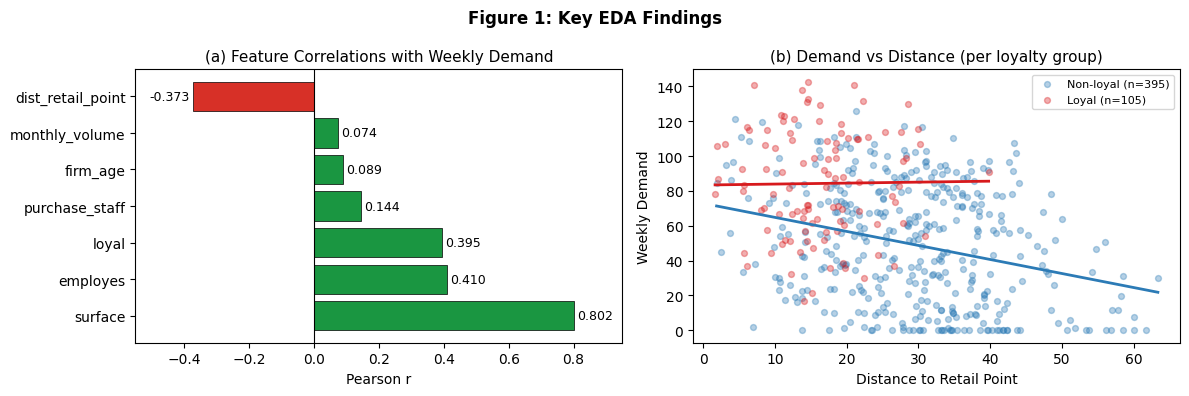

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) Correlations with demand
num_cols = ['surface','employes','purchase_staff','monthly_volume',
            'firm_age','dist_retail_point','loyal','demand']
corr_d = hist[num_cols].corr()['demand'].drop('demand').sort_values(ascending=False)
bar_colors = ['#1a9641' if v > 0 else '#d73027' for v in corr_d]
bars = axes[0].barh(corr_d.index, corr_d.values, color=bar_colors, edgecolor='black', lw=0.5)
axes[0].axvline(0, color='black', lw=0.8)
for bar, v in zip(bars, corr_d.values):
    axes[0].text(v + (0.01 if v>=0 else -0.01), bar.get_y()+bar.get_height()/2,
                 f'{v:.3f}', va='center', ha='left' if v>=0 else 'right', fontsize=9)
axes[0].set_title("(a) Feature Correlations with Weekly Demand", fontsize=11)
axes[0].set_xlabel("Pearson r"); axes[0].set_xlim(-0.55, 0.95)

# (b) Demand vs Distance coloured by loyalty — motivates keeping distance as a feature
for lv, col, lbl in [(0,'#2c7bb6','Non-loyal (n=395)'),(1,'#d7191c','Loyal (n=105)')]:
    g = hist[hist['loyal']==lv]
    axes[1].scatter(g['dist_retail_point'], g['demand'], alpha=0.35, s=18, color=col, label=lbl)
    z = np.polyfit(g['dist_retail_point'], g['demand'], 1)
    xr = np.linspace(g['dist_retail_point'].min(), g['dist_retail_point'].max(), 50)
    axes[1].plot(xr, np.polyval(z,xr), color=col, lw=2)
axes[1].set_xlabel("Distance to Retail Point"); axes[1].set_ylabel("Weekly Demand")
axes[1].set_title("(b) Demand vs Distance (per loyalty group)", fontsize=11)
axes[1].legend(fontsize=8)

plt.suptitle("Figure 1: Key EDA Findings", fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

**Takeaways:**
- **Surface (r = 0.80)** is the dominant predictor — larger firms order significantly more.
- **Distance (r = −0.37)** has a clear negative effect and must be kept in the model; its value will be pre-computed per client–site pair (see Section 3).
- **Loyal clients** have 72% higher mean demand (84.3 vs 49.1) and are on average 13 units closer to their retail point. This structural difference motivates Stage 2's segmented approach.
- `purchased_products` (r ≈ 0.04) is excluded: near-zero predictive value *and* unavailable for new clients.


## 2. Feature Selection

| Feature | Available for new clients? | Include? | Reason |
|---|---|---|---|
| `surface` | ✅ | ✅ | Strongest predictor (r = 0.80) |
| `employes` | ✅ | ✅ | Strong predictor (r = 0.41) |
| `purchase_staff` | ✅ | ✅ | Moderate positive effect |
| `firm_age` | ✅ | ✅ | Included (small but non-zero effect) |
| `monthly_volume` | ✅ | ✅ | Included |
| `dist_retail_point` | ❌ not observed | ✅ computed | Pre-computed as Euclidean distance to each candidate site |
| `purchased_products` | ❌ not in dataset | ❌ | Unavailable + near-zero correlation |
| `loyal` | ❌ unknown | ❌ S1 / ✅ S2 | Unknown for new clients; predicted via classifier in Stage 2 |


In [19]:
FEATURES = ['employes','surface','firm_age','monthly_volume','purchase_staff','dist_retail_point']
print("Final feature set:", FEATURES)

Final feature set: ['employes', 'surface', 'firm_age', 'monthly_volume', 'purchase_staff', 'dist_retail_point']


## 3. Demand Prediction Model

In [20]:
X = hist[FEATURES].values
y = hist['demand'].values
kf = KFold(n_splits=5, shuffle=True, random_state=42)

candidate_models = {
    "OLS Linear"      : Pipeline([('s', StandardScaler()), ('r', LinearRegression())]),
    "Ridge (α=1)"     : Pipeline([('s', StandardScaler()), ('r', Ridge(alpha=1.0))]),
    "Random Forest"   : RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
}

print(f"{'Model':22s}  {'CV R²':>15}  {'CV RMSE':>10}")
print("-" * 55)
cv_results = {}
for name, m in candidate_models.items():
    r2   = cross_val_score(m, X, y, cv=kf, scoring='r2')
    rmse = np.sqrt(-cross_val_score(m, X, y, cv=kf, scoring='neg_mean_squared_error'))
    cv_results[name] = {'r2': r2.mean(), 'r2_std': r2.std(), 'rmse': rmse.mean()}
    print(f"{name:22s}  {r2.mean():.4f} ±{r2.std():.4f}  {rmse.mean():10.3f}")

Model                             CV R²     CV RMSE
-------------------------------------------------------
OLS Linear              0.9194 ±0.0063      10.229
Ridge (α=1)             0.9194 ±0.0063      10.229
Random Forest           0.8874 ±0.0161      12.056
Gradient Boosting       0.8999 ±0.0163      11.363


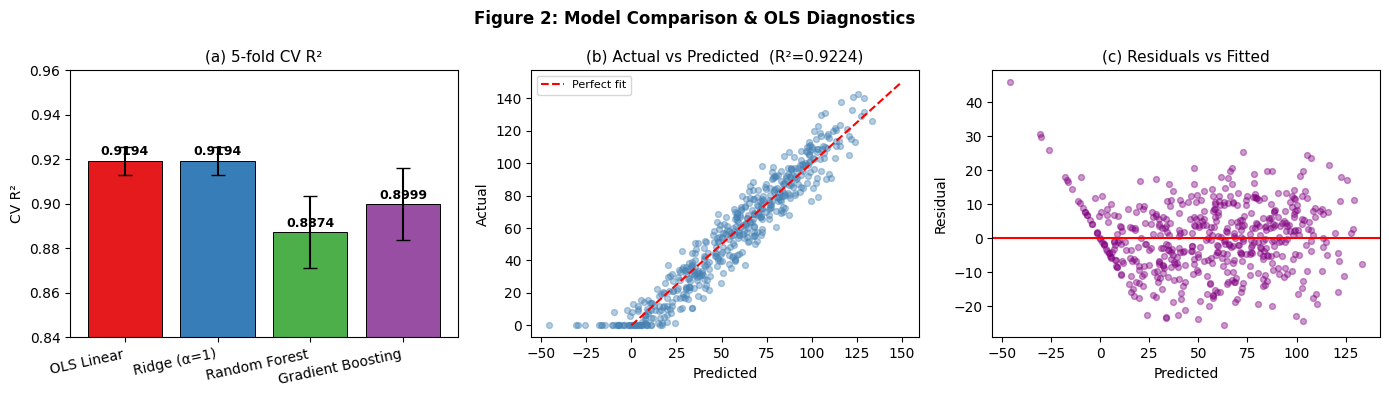


OLS standardised coefficients:
  surface                  : +27.8215
  dist_retail_point        : -13.6869
  employes                 : +12.7135
  purchase_staff           : +5.0529
  firm_age                 : +0.6216
  monthly_volume           : +0.2435


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors_m = ['#e41a1c','#377eb8','#4daf4a','#984ea3']
names = list(cv_results.keys())

bars = axes[0].bar(names, [cv_results[n]['r2'] for n in names],
                   yerr=[cv_results[n]['r2_std'] for n in names],
                   capsize=5, color=colors_m, edgecolor='black', lw=0.7)
axes[0].set_ylim(0.84, 0.96); axes[0].set_ylabel("CV R²")
axes[0].set_title("(a) 5-fold CV R²", fontsize=11)
axes[0].set_xticklabels(names, rotation=12, ha='right')
for bar, v in zip(bars, [cv_results[n]['r2'] for n in names]):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.001, f'{v:.4f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

# Fit OLS on full data for diagnostics
ols = Pipeline([('s',StandardScaler()),('r',LinearRegression())])
ols.fit(X, y)
y_pred = ols.predict(X)
resid  = y - y_pred

axes[1].scatter(y_pred, y, alpha=0.4, s=18, color='steelblue')
lim = max(y.max(), y_pred.max())*1.05
axes[1].plot([0,lim],[0,lim],'r--',lw=1.5,label='Perfect fit')
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].set_title(f"(b) Actual vs Predicted  (R²={r2_score(y,y_pred):.4f})", fontsize=11)
axes[1].legend(fontsize=8)

axes[2].scatter(y_pred, resid, alpha=0.4, s=18, color='purple')
axes[2].axhline(0, color='red', lw=1.5)
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Residual")
axes[2].set_title("(c) Residuals vs Fitted", fontsize=11)

plt.suptitle("Figure 2: Model Comparison & OLS Diagnostics", fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Coefficients
coefs = pd.Series(ols.named_steps['r'].coef_, index=FEATURES)
print("\nOLS standardised coefficients:")
for f, c in coefs.sort_values(key=abs, ascending=False).items():
    print(f"  {f:25s}: {c:+.4f}")

**Model selection: OLS Linear Regression**

OLS achieves the best CV R² (0.9194) with the lowest RMSE (10.23). The negligible gap with Ridge confirms no multicollinearity. Tree models underperform — confirming the relationships are predominantly linear, consistent with the high Pearson correlations.

OLS is also preferred because it will naturally produce **negative predictions** for very distant client–site pairs (linear extrapolation beyond the training distance range of 1.7–63.4 units), which the case explicitly requires clamping to zero. This cannot be observed with tree models.


## 4. Demand Matrix Generation (200 × 8)

### The circular dependency
Distance is a key feature in the model, but for potential clients it depends on which store is eventually opened. We resolve this by pre-computing the Euclidean distance between **every client–site pair** and running the model for each combination — producing a full demand matrix before any optimisation takes place.

$$\hat{d}_{i,j} = \max\bigl(0,\ \text{OLS}(\mathbf{x}_i,\ d_{i,j})\bigr) \quad \forall\, i \in \{1{,}\ldots,200\},\ j \in \{1{,}\ldots,8\}$$

Negative values are clamped to zero (23.9% of pairs, mainly clients far from all sites).


In [22]:
BASE = ['employes','surface','firm_age','monthly_volume','purchase_staff']

D_mat = cdist(pot[['lat','lon']].values, sites[['lat','lon']].values)  # (200, 8)

print(f"Training distance range   : {hist['dist_retail_point'].min():.1f} – {hist['dist_retail_point'].max():.1f}")
print(f"Client–site distance range: {D_mat.min():.1f} – {D_mat.max():.1f}  (extrapolation beyond training range)")

Demand = np.zeros((200, 8))
raw_neg = 0
for j in range(8):
    raw = ols.predict(np.hstack([pot[BASE].values, D_mat[:,j].reshape(-1,1)]))
    raw_neg += (raw < 0).sum()
    Demand[:,j] = np.maximum(0, raw)

print(f"\nNegative predictions clamped: {raw_neg}/1600  ({100*raw_neg/1600:.1f}%)")
print(f"Non-zero entries            : {(Demand>0).sum()}/1600")

Training distance range   : 1.7 – 63.4
Client–site distance range: 1.8 – 116.2  (extrapolation beyond training range)

Negative predictions clamped: 382/1600  (23.9%)
Non-zero entries            : 1218/1600


In [23]:
# Build and display the demand matrix
df_demand = pd.DataFrame(
    Demand.round(2),
    index=[f"Client_{i+1}" for i in range(200)],
    columns=[f"Site_{j+1}" for j in range(8)]
)
df_demand.index.name = "Client"

print("=== DEMAND MATRIX D̂[i,j] – first 10 rows ===")
print(df_demand.head(10).to_string())
print(f"\n... ({len(df_demand)} rows total)")

print("\n=== Per-site total potential demand ===")
totals = df_demand.sum().rename("Total demand")
print(totals.round(1).to_string())
print(f"\nGrand total (if all demand captured): {df_demand.values.sum():.1f}")

=== DEMAND MATRIX D̂[i,j] – first 10 rows ===
           Site_1  Site_2  Site_3  Site_4  Site_5  Site_6  Site_7  Site_8
Client                                                                   
Client_1     0.00    0.00    0.00    0.00    0.00    0.00    0.00    0.00
Client_2     0.00   19.18    0.00    0.00   16.04   14.27    1.40    3.20
Client_3    15.22    0.00    0.00    0.00    0.00    0.00    0.00   28.24
Client_4    33.97   67.18   48.42   63.39   83.36   67.65   56.69   54.14
Client_5    24.46   57.94   18.51   17.73   33.51   42.94   28.93   39.98
Client_6    40.39   51.26    2.47    6.72   25.76   26.88   12.85   69.11
Client_7     1.25    0.98    0.00    0.00    0.00    0.00    0.00   28.43
Client_8    57.49   91.80   87.68   71.20   76.52  110.94   98.34   59.69
Client_9    59.25   24.16    0.00    0.00    0.00    0.00    0.00   42.70
Client_10   27.48   63.95   70.49   97.53  115.67   79.93   75.05   44.00

... (200 rows total)

=== Per-site total potential demand ===
Sit

In [24]:
# Export full matrix to Excel for the Stage 2 comparison step
stage1_demand_path = OUTPUT_DIR / "demand_matrix_stage1.xlsx"
df_demand.to_excel(stage1_demand_path)
print(f"Full 200 x 8 demand matrix saved to: {stage1_demand_path}")


Full 200 x 8 demand matrix saved to: outputs\demand_matrix_stage1.xlsx


## 5. Optimization Model

We now pass the Stage 1 demand matrix into the shared MILP optimization model. The model decides:

- which candidate sites to open,
- whether each opened store is small or large,
- which clients are assigned to each opened store,
- which clients remain unassigned.


In [25]:
demand_for_optimization = pd.DataFrame(Demand, index=pot.index, columns=sites.index)

result_s1 = solve_location_model(
    demand_matrix=demand_for_optimization,
    candidate_sites=sites,
    budget=850,
    verbose=False,
)

print(f"Total captured demand : {result_s1['objective_value']:.1f} units/week")
print(f"Budget used           : {result_s1['budget_used']:.0f} / 850 kEUR")
print(f"Clients assigned      : {len(result_s1['assignments'])} / {len(pot)}")
print(f"Clients unassigned    : {len(result_s1['unassigned_clients'])}")


Total captured demand : 12696.9 units/week
Budget used           : 806 / 850 kEUR
Clients assigned      : 189 / 200
Clients unassigned    : 11


### 5.1 Selected Sites and Store Formats

In [26]:
selected_sites_s1 = result_s1["selected_sites"]
selected_sites_s1


,site_id,format,capacity,cost,used_capacity,capacity_utilization
0,Site 1,small,2500.0,144.0,1918.526523,0.767411
1,Site 2,small,2800.0,158.0,2780.047816,0.992874
2,Site 5,small,2500.0,144.0,2218.128581,0.887251
3,Site 7,large,4200.0,207.0,3434.580247,0.817757
4,Site 8,small,2700.0,153.0,2345.618630,0.868748


### 5.2 Client Assignments

In [27]:
assignments_s1 = result_s1["assignments"]
assignments_s1.head(10)


,client_id,site_id,captured_demand
0,1,Site 2,19.178108
1,2,Site 8,28.235925
2,3,Site 5,83.355579
3,4,Site 2,57.935011
4,5,Site 8,69.108029
5,6,Site 8,28.432955
6,7,Site 7,98.342569
7,8,Site 1,59.246290
8,9,Site 5,115.673339
9,10,Site 2,103.928859


### 5.3 Capacity Utilization

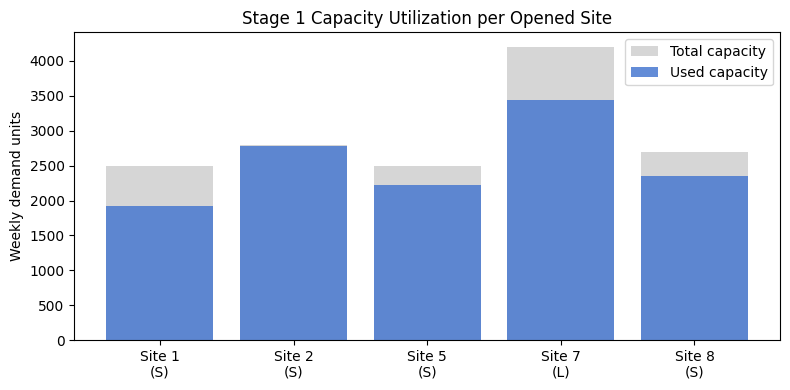

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))
labels = [f"{row['site_id']}\n({row['format'][0].upper()})" for _, row in selected_sites_s1.iterrows()]
x = np.arange(len(selected_sites_s1))

ax.bar(x, selected_sites_s1["capacity"], color="#BBBBBB", alpha=0.6, label="Total capacity")
ax.bar(x, selected_sites_s1["used_capacity"], color="#4878D0", alpha=0.85, label="Used capacity")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Weekly demand units")
ax.set_title("Stage 1 Capacity Utilization per Opened Site")
ax.legend()
plt.tight_layout()
plt.show()


### 5.4 Assignment Map

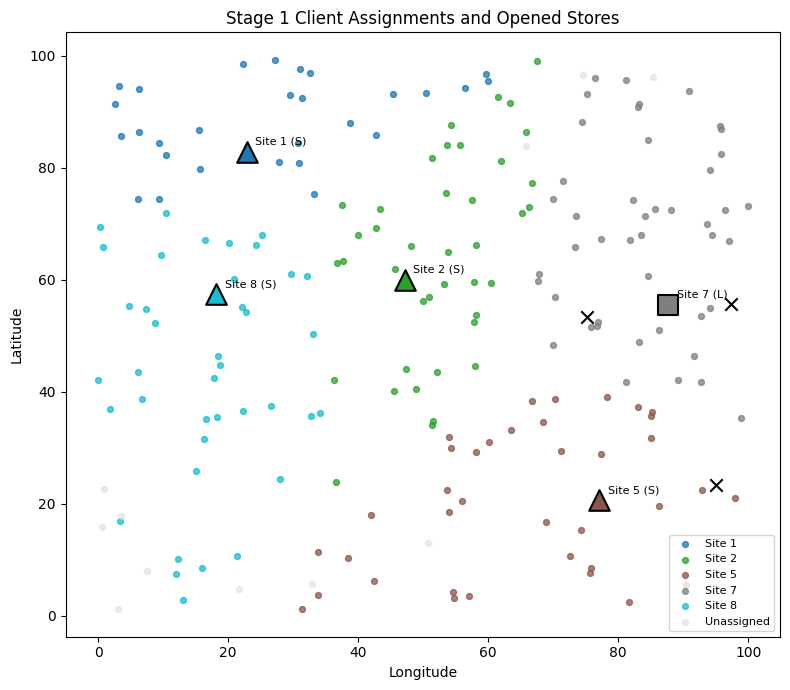

In [29]:
site_list = list(selected_sites_s1["site_id"])
site_colors = plt.cm.tab10(np.linspace(0, 1, len(site_list)))
color_map = dict(zip(site_list, site_colors))
assigned_to = dict(zip(assignments_s1["client_id"], assignments_s1["site_id"]))

fig, ax = plt.subplots(figsize=(8, 7))

# assigned clients
for site_id in site_list:
    client_ids = [client for client, site in assigned_to.items() if site == site_id]
    sub = pot.loc[client_ids]
    ax.scatter(sub["lon"], sub["lat"], s=18, alpha=0.75, color=color_map[site_id], label=site_id)

# unassigned clients
if result_s1["unassigned_clients"]:
    sub = pot.loc[result_s1["unassigned_clients"]]
    ax.scatter(sub["lon"], sub["lat"], s=18, alpha=0.55, color="#DDDDDD", label="Unassigned")

# candidate and opened sites
for site_id, row in sites.iterrows():
    opened = selected_sites_s1[selected_sites_s1["site_id"] == site_id]
    if opened.empty:
        ax.scatter(row["lon"], row["lat"], marker="x", s=80, color="black")
    else:
        fmt = opened.iloc[0]["format"]
        marker = "s" if fmt == "large" else "^"
        ax.scatter(row["lon"], row["lat"], marker=marker, s=220,
                   color=color_map[site_id], edgecolors="black", linewidths=1.5)
        ax.annotate(f"{site_id} ({fmt[0].upper()})", (row["lon"], row["lat"]),
                    textcoords="offset points", xytext=(6, 5), fontsize=8)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Stage 1 Client Assignments and Opened Stores")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


### 5.5 Save Stage 1 Outputs

The plots are displayed directly in the notebook. The demand matrix and optimization result tables are saved as Excel files so Stage 2 can compare against the Stage 1 solution using the same file format.


In [30]:
with pd.ExcelWriter(OUTPUT_DIR / "stage1_optimization_results.xlsx") as writer:
    selected_sites_s1.to_excel(writer, sheet_name="selected_sites", index=False)
    assignments_s1.to_excel(writer, sheet_name="assignments", index=False)

print("Saved:")
print(f"- {OUTPUT_DIR / 'demand_matrix_stage1.xlsx'}")
print(f"- {OUTPUT_DIR / 'stage1_optimization_results.xlsx'}")


Saved:
- outputs\demand_matrix_stage1.xlsx
- outputs\stage1_optimization_results.xlsx


## 6. Summary

| Item | Value |
|---|---|
| Training data | 500 historic clients |
| Model selected | OLS Linear Regression |
| Features used | surface, employes, firm_age, monthly_volume, purchase_staff, dist_retail_point |
| Excluded | `purchased_products` unavailable for potential clients; `loyal` handled in Stage 2 |
| Demand matrix | 200 x 8 client-site matrix |
| Optimization model | Shared MILP implemented in `opticlean_optimization.py` |

The Stage 1 output is a baseline network design built from a single demand model. Stage 2 will use the same optimization model but replace the demand matrix with one based on predicted loyalty and segmented demand models.
